<a href="https://colab.research.google.com/github/vaisshnavee1410/KNN.ipynb/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-NEAREST NEIGHBOURS**

## **Objective:**

* **The objective of this assignment is to implement and evaluate the K-Nearest Neighbours algorithm for classification using the given datasets**

## **Dataset:**

* **Need to Classify the animal type**

In [12]:
import pandas as pd
import numpy as np

# Load the dataset
data = pd.read_csv('Zoo.csv')

# Display first few rows
data.head()


,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


## **Tasks:**

* **Analyse the data using the visualizations**

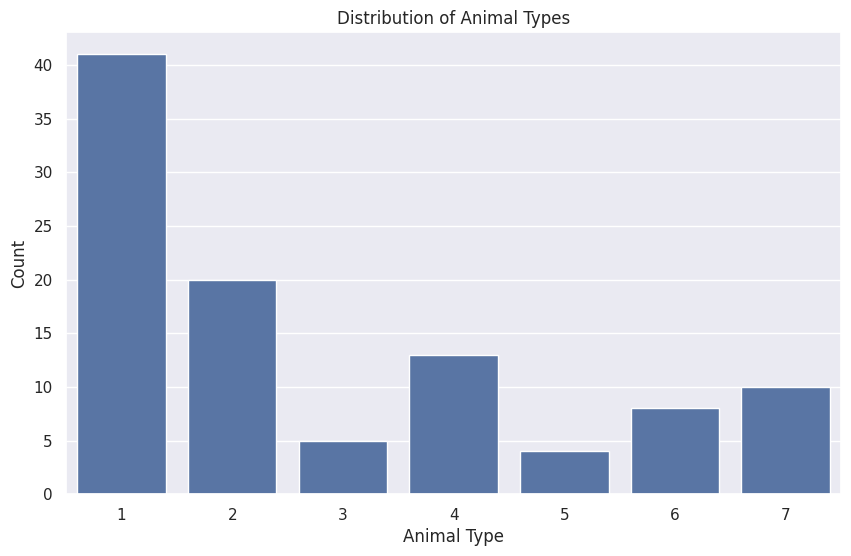

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="darkgrid")

# Countplot of animal types
plt.figure(figsize=(10, 6))
sns.countplot(x='type', data=data)
plt.title('Distribution of Animal Types')
plt.xlabel('Animal Type')
plt.ylabel('Count')
plt.show()

* **Preprocess the data by handling missing values & Outliers, if any.**

Missing Values:
 animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

Dataset Description:
              hair    feathers        eggs        milk    airborne     aquatic  \
count  101.000000  101.000000  101.000000  101.000000  101.000000  101.000000   
mean     0.425743    0.198020    0.584158    0.405941    0.237624    0.356436   
std      0.496921    0.400495    0.495325    0.493522    0.427750    0.481335   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
50%      0.000000    0.000000    1.000000    0.000000    0.000000    0.000000   
75%      1.000000    0.000000    1.000000    1.000000    0.000000    1.000

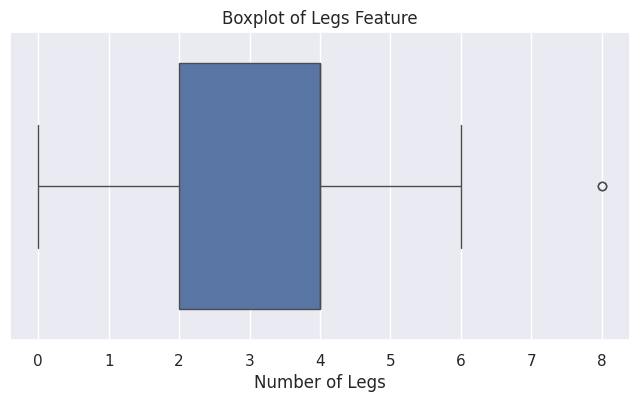


Outliers in 'legs' feature:
    animal name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
85    starfish     0         0     1     0         0        1         1   

    toothed  backbone  breathes  venomous  fins  legs  tail  domestic  \
85        0         0         0         0     0     5     0         0   

    catsize  type  
85        0     7  


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Zoo.csv")

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Summary statistics
print("\nDataset Description:\n", df.describe())

# Visualize 'legs' feature to identify outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x='legs', data=df)
plt.title('Boxplot of Legs Feature')
plt.xlabel('Number of Legs')
plt.show()

# Detect rows with outlier leg values
valid_leg_values = {0, 2, 4, 6, 8}
outlier_legs = df[~df['legs'].isin(valid_leg_values)]

print("\nOutliers in 'legs' feature:\n", outlier_legs)

# Since the outlier (starfish with 5 legs) is biologically valid, we retain it
# No missing values to handle
# Preprocessing complete

* **Split the dataset into training and testing sets (80% training, 20% testing).**

In [15]:
from sklearn.model_selection import train_test_split

# Drop the 'animal name' column (not useful for classification)
X = df.drop(columns=['animal name', 'type'])  # Features
y = df['type']  # Target variable

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # maintain class distribution
)

# Display the shape of the resulting sets
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training features shape: (80, 16)
Testing features shape: (21, 16)
Training labels shape: (80,)
Testing labels shape: (21,)


* **Implement the K-Nearest Neighbours algorithm using a machine learning library like scikit-learn On training dataset.**

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize the KNN classifier with k=3 (you can tune this later)
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model on the training set
knn.fit(X_train, y_train)

# Predict on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 0.9047619047619048

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       0.00      0.00      0.00         1
           4       0.75      1.00      0.86         3
           5       0.50      1.00      0.67         1
           6       1.00      1.00      1.00         2
           7       1.00      0.50      0.67         2

    accuracy                           0.90        21
   macro avg       0.75      0.79      0.74        21
weighted avg       0.89      0.90      0.88        21


Confusion Matrix:
 [[8 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 0 1 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 2 0]
 [0 0 0 0 1 0 1]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


* **Choose an appropriate distance metric and value for K.**

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model
knn = KNeighborsClassifier()
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN model
knn = KNeighborsClassifier()

# Use GridSearchCV to find the best parameters
grid_search = GridSearchCV(estimator=knn, param_grid={}) # Add parameters to param_grid

grid_search.fit(X_train, y_train)

# Output the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Output the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {}
Best Cross-Validation Accuracy: 0.8375
Best Parameters: {}
Best Cross-Validation Accuracy: 0.8375


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


* **Evaluate the classifier's performance on the testing set using accuracy, precision, recall, and F1-score metrics.**

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Get the best estimator from GridSearchCV
best_knn = grid_search.best_estimator_

# Predict on the test set
y_pred = best_knn.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Print results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")

# Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.9524
Precision (weighted): 0.9167
Recall (weighted): 0.9524
F1 Score (weighted): 0.9320

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       0.00      0.00      0.00         1
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           0.95        21
   macro avg       0.82      0.86      0.84        21
weighted avg       0.92      0.95      0.93        21



* **Visualize the decision boundaries of the classifier.**

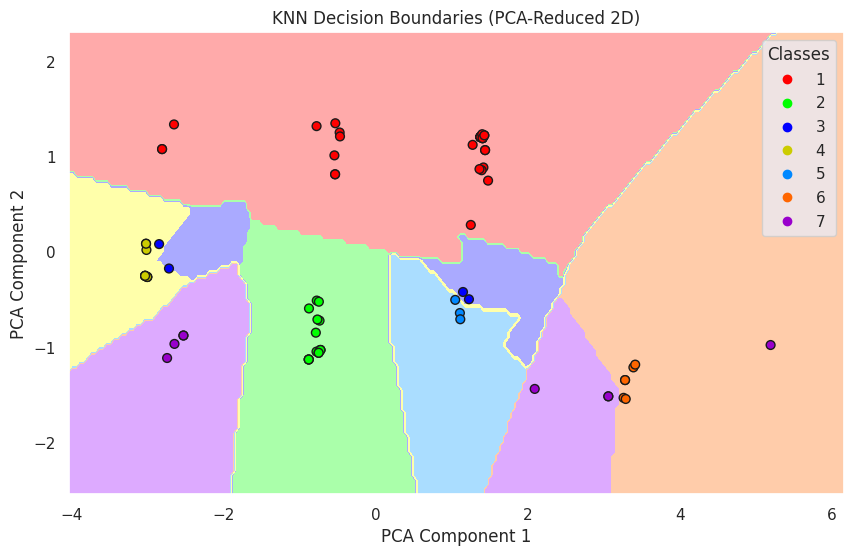

In [19]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

# Reduce features to 2D using PCA for visualization
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train)
X_test_2D = pca.transform(X_test)

# Train a new KNN model on the 2D-transformed training data
knn_2D = KNeighborsClassifier(n_neighbors=3)
knn_2D.fit(X_train_2D, y_train)

# Plot decision boundaries
h = .05  # step size in the mesh
x_min, x_max = X_train_2D[:, 0].min() - 1, X_train_2D[:, 0].max() + 1
y_min, y_max = X_train_2D[:, 1].min() - 1, X_train_2D[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_2D.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Define color map
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA', '#AADDFF', '#FFCCAA', '#DDAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF', '#CCCC00', '#0088FF', '#FF6600', '#9900CC'])

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
scatter = plt.scatter(X_train_2D[:, 0], X_train_2D[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=40)
plt.legend(*scatter.legend_elements(), title="Classes", loc="upper right")
plt.title("KNN Decision Boundaries (PCA-Reduced 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## **Interview Questions:**

* **What are the key hyperparameters in KNN?**

1.**N_neighbors (K):**

•	What it does: Specifies the number of nearest neighbors to consider when making a prediction.

•	Effect:
•	Low K (e.g., 1): Highly flexible, can overfit (very sensitive to noise).

•	High K (e.g., 15+): Smoother decision boundaries, may underfit (less responsive to local patterns).

•	Typical range: 3–15, chosen using cross-validation.

2.**Metric:**

•	**What it does:**

Defines the distance function used to compute similarity between points.

•	**'manhattan':**

 Sum of absolute differences (good for grid-like data).

•	**'minkowski':**

Generalized form (you can tune p).

•	**'chebyshev':**

 Maximum difference along any coordinate dimension.

•	**Effect:**

Different metrics can capture different shapes of similarity in the feature space.

3. **Weights:**

•	What it does: Determines how the neighbors contribute to the prediction.

•	'uniform': All neighbors contribute equally (default).

•	'distance': Closer neighbors have a stronger influence.

•	Effect: distance weighting often improves performance when data is unevenly spaced.

4. **Algorithm:**

•	What it does: Determines the search algorithm for finding nearest neighbors.

•	Options:
•	'auto', 'ball_tree', 'kd_tree', 'brute'

•	Effect: Affects performance (speed), not accuracy. Relevant for large datasets.

5. **leaf_size (used with tree-based algorithms)**

•	What it does: Affects the speed of the tree-based algorithms (ball_tree or kd_tree).

•	Effect: Trade-off between training and query speed. Typically doesn’t affect accuracy much.




* **What distance metrics can be used in KNN?**

In K-Nearest Neighbors (KNN), the distance metric is a critical component because it determines how similarity between data points is measured. The most commonly used metric is Euclidean distance, which calculates the straight-line distance between two points in space and is best suited for continuous, normalized data. When features are not normalized or when movement is restricted to grid-like paths, the Manhattan distance (also known as L1 norm) is often more appropriate, as it sums the absolute differences between feature values.

A more general form is the Minkowski distance, which introduces a parameter p that allows tuning the metric between Manhattan (p=1) and Euclidean (p=2) distances. Another option is the Chebyshev distance, which considers only the largest difference in any one dimension, making it useful in specific scenarios where maximum deviation is critical. For binary or categorical data, the Hamming distance is preferred as it counts the number of differing attributes.

Lastly, in high-dimensional sparse data such as text embeddings or document vectors, Cosine distance is often used because it measures the angle between two vectors, focusing more on direction than magnitude. Choosing the right distance metric depends on the nature of the features in your dataset, and selecting an appropriate one can significantly impact the model’s classification accuracy.